# 1. Imports

In [68]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, chi2_contingency, ttest_ind
import matplotlib.patches as mpatches

sys.path.append('../utils')
from myutils import display_report

print("Libraries loaded.")

Библиотеки загружены.


# 2. Loading All Datasets

In [69]:
BASE = "../data/clean/"

deals    = pd.read_pickle(BASE + "deals_clean.pkl")
spend    = pd.read_pickle(BASE + "spend_clean.pkl")
contacts = pd.read_pickle(BASE + "contacts_clean.pkl")

paid_deals = deals[deals["Is Paid"]].copy()

print(f"deals    : {deals.shape}")
print(f"spend    : {spend.shape}")
print(f"contacts : {contacts.shape}")
print(f"paid_deals: {len(paid_deals):,}")

deals    : (21593, 30)
spend    : (19573, 12)
contacts : (18548, 7)
paid_deals: 858


# Revenue Calculation

In [70]:
# One Payment:
#   Revenue = Initial Amount Paid
#
# Recurring Payments:
#   Revenue = Initial Amount Paid
#             + (Offer Total Amount - Initial Amount Paid)
#               / (Course duration - 1)
#               * (Months of study - 1)
#
# No Payment / other cases -> 0

def calculate_revenue(row):
    payment_type = row["Payment Type"]
    initial = row["Initial Amount Paid"]
    offer_total = row["Offer Total Amount"]
    course_duration = row["Course duration"]
    months_studied = row["Months of study"]

    if payment_type == "One Payment":
        if pd.notna(initial):
            return float(initial)
        if pd.notna(offer_total):
            return float(offer_total)
        return 0.0

    if payment_type == "Recurring Payments":
        if pd.isna(initial) or pd.isna(offer_total):
            return 0.0
        if pd.isna(course_duration) or float(course_duration) <= 1:
            return float(initial)
        if pd.isna(months_studied) or float(months_studied) < 0:
            return float(initial)

        remaining_amount   = float(offer_total) - float(initial)
        installment_months = float(course_duration) - 1
        earned_months      = float(months_studied) - 1

        if earned_months < 0:
            return float(initial)

        monthly_payment = remaining_amount / installment_months
        return float(initial) + monthly_payment * earned_months

    return 0.0


deals["Revenue"] = deals.apply(calculate_revenue, axis=1)
paid_deals = deals[deals["Is Paid"]].copy()

print("Formula validation:")
print("Initial=500, Offer=4500, Duration=11, Months=3")
print("Expected: 500 + (4500-500)/(11-1)*(3-1) = 1300")

test = pd.Series({
    "Payment Type":        "Recurring Payments",
    "Initial Amount Paid": 500,
    "Offer Total Amount":  4500,
    "Course duration":     11,
    "Months of study":     3,
})

print(f"Result: €{calculate_revenue(test):,.0f}")
print()
print(f"Total actual revenue : €{paid_deals['Revenue'].sum():,.0f}")
print(f"Contract value       : €{paid_deals['Offer Total Amount'].sum():,.0f}")
print(f"Remaining revenue    : €{paid_deals['Offer Total Amount'].sum() - paid_deals['Revenue'].sum():,.0f}")

Проверка формулы:
Initial=500, Offer=4500, Duration=11, Months=3
Ожидается: 500 + (4500-500)/(11-1)*(3-1) = 1300
Результат: €1,300

Общая фактическая выручка : €3,502,771
Контрактная сумма          : €6,355,601
Ещё не заработано          : €2,852,830


# TRANSACTION CALCULATION

In [71]:
# Logic (similar to Revenue calculation):
#
# One Payment:
#   transactions = 1
#   (one payment = the full amount paid at once)
#
# Recurring Payments:
#   transactions = 1 (initial payment) + (Months of study - 1)
#   (initial payment + each following month = separate transaction)
#   In other words: number of study months = number of payments
#   (first month is covered by the initial payment, then one payment per month)
#
# No Payment / other cases:
#   transactions = 0
#
# Example Recurring:
#   Course duration = 11, Months of study = 3
#   transactions = 1 + (3 - 1) = 3
#   (initial payment + 2 monthly payments)


# Creating Is Valid Buyer:
# [Is Paid] = TRUE
# AND NOT ISNULL([Initial Amount Paid])
# AND NOT ISNULL([Offer Total Amount])

deals["Is Valid Buyer"] = (
    (deals["Is Paid"] == True)
    & deals["Initial Amount Paid"].notna()
    & deals["Offer Total Amount"].notna()
)


# Transaction count calculation

def calculate_transactions(row):
    """
    Calculates the number of payment transactions per deal.
    Logic is aligned with the Revenue calculation.
    """
    payment_type = row["Payment Type"]
    months_studied = row["Months of study"]

    # One Payment: one payment, one transaction
    if payment_type == "One Payment":
        return 1

    # Recurring Payments: initial + monthly payments
    if payment_type == "Recurring Payments":
        if pd.isna(months_studied) or float(months_studied) < 0:
            return 1  # at least the initial payment was made
        
        months = float(months_studied)

        if months < 1:
            return 1  # first month = initial payment
        
        # 1 (initial payment) + (months - 1) additional payments
        return int(1 + max(0, months - 1))

    # No Payment / Not Specified / Reservation
    return 0


# Apply transaction calculation
deals["Transactions"] = deals.apply(calculate_transactions, axis=1)


# Transaction distribution check
print("Transaction distribution:")
print(deals["Transactions"].value_counts().sort_index())


print(f"\nTotal number of transactions: {deals['Transactions'].sum():,}")

print(
    f"Average transactions per buyer: "
    f"{deals[deals['Is Valid Buyer']]['Transactions'].mean():.2f}"
)


# Breakdown by payment type
trans_by_type = (
    deals[deals["Transactions"] > 0]
    .groupby("Payment Type", observed=True)
    .agg(
        buyers=("Id", "count"),
        total_trans=("Transactions", "sum"),
        avg_trans=("Transactions", "mean"),
        avg_revenue=("Revenue", "mean"),
        avg_per_trans=("Revenue", lambda x:
                       x.sum() / deals.loc[x.index, "Transactions"].sum()),
    )
    .reset_index()
)

print("\nTransactions by Payment Type:")
print(trans_by_type.to_string(index=False))


# Revenue per transaction
deals["Revenue Per Transaction"] = np.where(
    deals["Transactions"] > 0,
    deals["Revenue"] / deals["Transactions"],
    0.0
)


# Only Valid Buyers (same as Tableau filter)
paid_valid = deals[deals["Is Valid Buyer"]].copy()


avg_rev_per_trans = paid_valid["Revenue Per Transaction"].mean()


print(f"\nAverage revenue per transaction: €{avg_rev_per_trans:,.0f}")

print(
    f"Average course value (AOV): "
    f"€{paid_valid['Revenue'].mean():,.0f}"
)

Транзакции — распределение:
Transactions
0     20623
1       305
2        88
3        79
4        76
5        49
6        95
7        72
8        76
9        53
10       38
11       39
Name: count, dtype: int64

Общее количество транзакций    : 4,235
Средних транзакций/покупателя  : 4.87

Транзакции по типу оплаты:
      Payment Type  buyers  total_trans  avg_trans  avg_revenue  avg_per_trans
       One Payment     152          152   1.000000  2598.368421    2598.368421
Recurring Payments     818         4083   4.991443  3995.073350     800.384521

Средний чек за 1 транзакцию   : €1,098
Средний чек за курс (AOV)      : €4,155


# BLOCK 1: UNIT ECONOMICS

# 3. Metric Definitions

In [72]:
# METRIC DEFINITIONS
#
# UA   = Users Acquired  — total leads (contacts)
# B    = Buyers          — customers who made a payment (Is Paid = True)
# C1   = B / UA * 100    — lead-to-customer conversion rate
# AC   = total Spend     — advertising costs
#
# Revenue:
#   One Payment    -> Initial Amount Paid
#   Recurring      -> Initial + remaining amount / (Duration - 1) * (Months - 1)
#
# AOV  = Revenue / T
# APC (average number of payments) = T / B
#
# CAC  = AC / B
# COGS = Revenue * 30%   (salaries, platform, support)
# CM   = Revenue - AC - COGS
# CM1  = AOV - CAC - AOV*30%
# CLTV = AOV (single course, no repeat purchases)
# CPA  = AC / UA

COGS_RATE = 0
print(f"COGS_RATE = {COGS_RATE}")

COGS_RATE = 0


# 4. Global Unit Economics

In [73]:
paid_deals = deals[
    deals["Is Paid"]
    & deals["Revenue"] > 0
    & deals["Initial Amount Paid"].notna()
    & deals["Offer Total Amount"].notna()
].copy()

In [74]:
UA           = len(contacts)
B            = len(paid_deals)
C1           = B / UA * 100 if UA > 0 else 0
AC           = spend["Spend"].sum()
revenue      = paid_deals["Revenue"].sum()
#AOV          = paid_deals["Revenue"].mean()
AOV          = (paid_deals["Revenue"].sum()/
                deals["Transactions"].sum())
COGS         = revenue * COGS_RATE
CAC          = AC / B if B > 0 else 0
CM           = revenue - AC - COGS
CM1          = AOV - CAC - (AOV * COGS_RATE)
CLTV         = (AOV-COGS_RATE)*APC
CPA          = AC / UA if UA > 0 else 0
total_clicks = spend["Clicks"].sum()
CPC          = AC / total_clicks if total_clicks > 0 else 0

contract_rev = paid_deals["Offer Total Amount"].sum()
unrealized   = contract_rev - revenue
APC          = (deals["Transactions"].sum() / B)


print("=" * 64)
print("  Global Unit Economics")
print("=" * 64)
print(f"  UA  (total leads)                 : {UA:>10,}")
print(f"  B   (buyers)                      : {B:>10,}")
print(f"  C1  (conversion rate %)           : {C1:>10.2f}%")
print(f"  AC  (advertising costs, €)        : €{AC:>9,.0f}")
print()
print(f"  Revenue (actual revenue, €)       : €{revenue:>9,.0f}")
print(f"  Contract Revenue (contract value, €): €{contract_rev:>9,.0f}")
print(f"  T   (Transactions)                : €{deals['Transactions'].sum()}")
print(f"  Unrealized (remaining revenue, €) : €{unrealized:>9,.0f}")
print()
print(f"  AOV                               : €{AOV:>9,.0f}")
print(f"  APC (Average Payment Count)       :  {APC:>.2f}")
print(f"  COGS (€)                          : €{COGS:>9,.0f}")
print(f"  CAC (customer acquisition cost, €): €{CAC:>9,.0f}")
print(f"  CLTV (customer lifetime value, €) : €{CLTV:>9,.0f}")
print(f"  CM  (contribution margin, €)      : €{CM:>9,.0f}")
print(f"  CM1 (profit per customer, €)      : €{CM1:>9,.0f}")
print(f"  CPA (cost per lead, €)            : €{CPA:>9,.2f}")
print(f"  CPC (cost per click, €)           : €{CPC:>9,.2f}")
print("=" * 64)

  ГЛОБАЛЬНАЯ ЮНИТ-ЭКОНОМИКА
  UA  (всего лидов)                 :     18,548
  B   (покупателей)                 :        839
  C1  (конверсия %)                 :       4.52%
  AC  (рекламные расходы, €)        : €  149,523

  Revenue (факт. выручка, €)        : €3,502,771
  Contract Revenue (контракт, €)    : €6,353,101
  T  (Transactions)                 : €4235
  Unrealized (ещё не заработано, €) : €2,850,330

  AOV                               : €      827
  APC (Average Payment Count)       :  5.05
  COGS (€)                          : €        0
  CAC  (стоимость покупателя, €)    : €      178
  CLTV (ценность клиента, €)        : €    4,175
  CM   (маржинальная прибыль, €)    : €3,353,248
  CM1  (прибыль/покупатель, €)      : €      649
  CPA  (стоимость лида, €)          : €     8.06
  CPC  (стоимость клика, €)         : €     0.36


# 5. Unit Economics by Product

In [75]:
deals_prod = deals[
    ~deals["Product"].isin(["Not Our Student"])
].copy()

product_ue = (
    deals_prod
    .groupby("Product", observed=True)
    .agg(
        ua=("Id", "count"),
        b=("Is Paid", "sum"),
        revenue=("Revenue", lambda x: x[deals_prod.loc[x.index, "Is Paid"]].sum()),
        aov=("Revenue", lambda x: x[deals_prod.loc[x.index, "Is Paid"]].mean()),
        contract_total=("Offer Total Amount", "sum"),
    )
    .reset_index()
)

# UA is the same for all products
product_ue["ua"] = 18548

total_ua_known = product_ue["ua"].sum()

product_ue["ac"] = (product_ue["ua"] / total_ua_known) * AC

product_ue["c1"] = (
    product_ue["b"] / product_ue["ua"] * 100
).round(2)

product_ue["cac"] = (
    product_ue["ac"] / product_ue["b"]
).round(2)

product_ue["cogs"] = (
    product_ue["revenue"] * COGS_RATE
).round(2)

product_ue["cm"] = (
    product_ue["revenue"] - product_ue["ac"] - product_ue["cogs"]
).round(2)

product_ue["cm1"] = (
    product_ue["aov"] - product_ue["cac"]
    - product_ue["aov"] * COGS_RATE
).round(2)

product_ue["cpa"] = (
    product_ue["ac"] / product_ue["ua"]
).round(2)

product_ue["cltv"] = product_ue["aov"].round(2)

product_ue["cltv_cac"] = (
    product_ue["cltv"] / product_ue["cac"]
).round(2)

product_ue["unrealized"] = (
    product_ue["contract_total"] - product_ue["revenue"]
).round(2)

product_ue = product_ue.sort_values("revenue", ascending=False)

print("Unit Economics by Product:")
print(product_ue[[
    "Product","ua","b","c1","revenue","aov",
    "cac","cm","cm1","cltv_cac","unrealized"
]].to_string(index=False))

Юнит-экономика по продуктам:
            Product    ua   b   c1   revenue         aov      cac         cm       cm1  cltv_cac  unrealized
  Digital Marketing 18548 474 2.56 2209075.0 4660.495781    63.09 2179170.31   4597.41     73.87  15809443.0
       UX/UI Design 18548 229 1.23  936015.0 4087.401747   130.59  906110.31   3956.81     31.30   7970385.0
      Web Developer 18548 137 0.74  357680.0 2610.802920   218.28  327775.31   2392.52     11.96   2540120.0
Find yourself in IT 18548   1 0.01       1.0    1.000000 29904.69  -29903.69 -29903.69      0.00         0.0
     Data Analytics 18548   0 0.00       0.0         NaN      inf  -29904.69       NaN       NaN      6000.0


# 6. Unit Economics Visualization

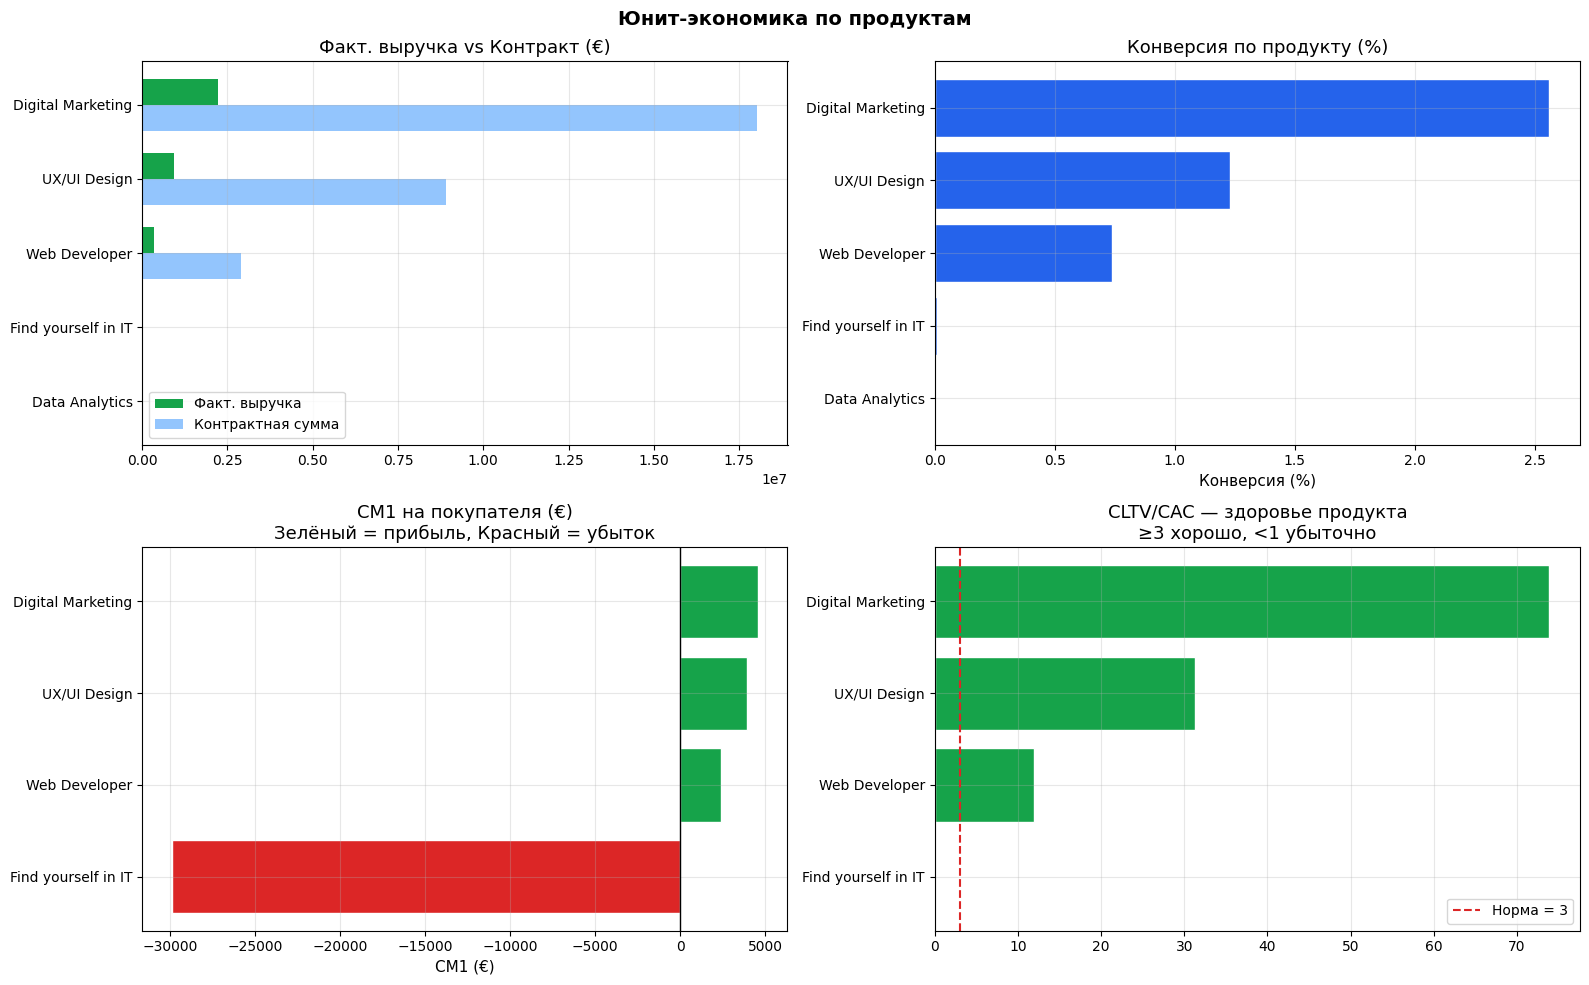

In [76]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Actual revenue vs contract value
x = range(len(product_ue))
width = 0.35

axes[0,0].barh(
    [i + width/2 for i in x],
    product_ue["revenue"][::-1],
    width, color="#16A34A", label="Actual Revenue"
)
axes[0,0].barh(
    [i - width/2 for i in x],
    product_ue["contract_total"][::-1],
    width, color="#93C5FD", label="Contract Value"
)
axes[0,0].set_yticks(list(x))
axes[0,0].set_yticklabels(product_ue["Product"][::-1])
axes[0,0].set_title("Actual Revenue vs Contract Value (€)")
axes[0,0].legend()

# Conversion rate
axes[0,1].barh(
    product_ue["Product"][::-1],
    product_ue["c1"][::-1],
    color="#2563EB", edgecolor="white"
)
axes[0,1].set_title("Conversion Rate by Product (%)")
axes[0,1].set_xlabel("Conversion Rate (%)")

# CM1
colors_cm1 = [
    "#16A34A" if v > 0 else "#DC2626"
    for v in product_ue["cm1"][::-1]
]

axes[1,0].barh(
    product_ue["Product"][::-1],
    product_ue["cm1"][::-1],
    color=colors_cm1, edgecolor="white"
)
axes[1,0].axvline(0, color="black", linewidth=1)
axes[1,0].set_title(
    "CM1 per Customer (€)\nGreen = Profit, Red = Loss"
)
axes[1,0].set_xlabel("CM1 (€)")

# CLTV/CAC ratio
colors_ratio = [
    "#16A34A" if v >= 3
    else "#F59E0B" if v >= 1
    else "#DC2626"
    for v in product_ue["cltv_cac"][::-1]
]

axes[1,1].barh(
    product_ue["Product"][::-1],
    product_ue["cltv_cac"][::-1],
    color=colors_ratio, edgecolor="white"
)
axes[1,1].axvline(
    3, color="#DC2626", linestyle="--", label="Benchmark = 3"
)
axes[1,1].set_title(
    "CLTV/CAC Ratio — Product Health\n≥3 Good, <1 Loss-Making"
)
axes[1,1].legend()

plt.suptitle(
    "Unit Economics by Product",
    fontsize=14, fontweight="bold"
)

plt.tight_layout()
plt.show()

# BLOCK 2: GROWTH OPPORTUNITIES

# 7. SLA and Conversion

Конверсия и выручка по корзинам SLA:
SLA Bucket  total  paid   revenue  conversion_pct  avg_revenue
  0–30 мин   2133   131  616340.0            6.14       4705.0
 30–60 мин   1339    80  327590.0            5.97       4095.0
  1–2 часа   1581    94  407400.0            5.95       4334.0
  2–4 часа   1806    92  415575.0            5.09       4517.0
 4–8 часов   1797    90  286240.0            5.01       3180.0
  8+ часов   6877   344 1522145.0            5.00       4425.0


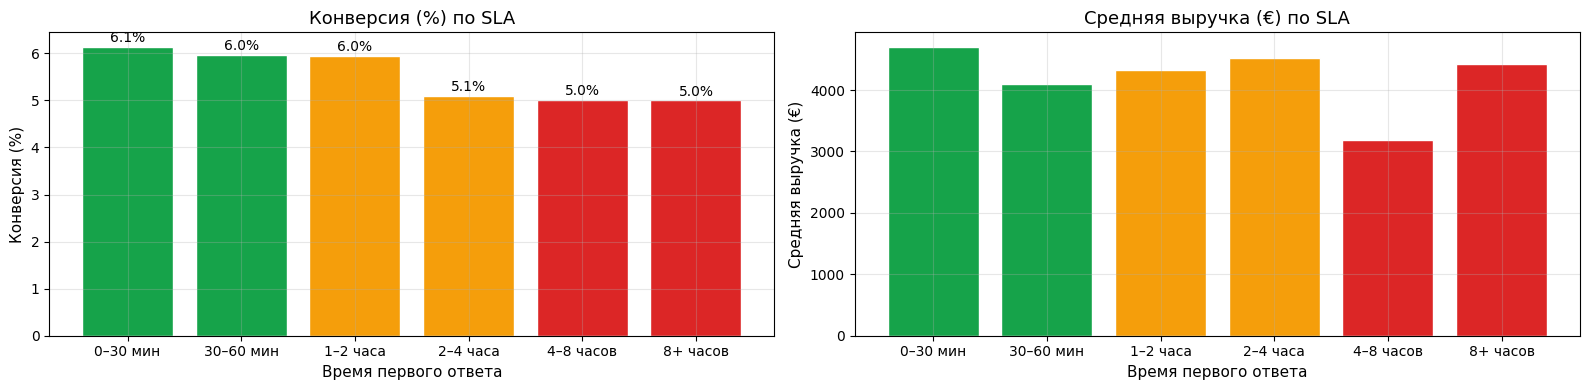


Лучшая конверсия: 0–30 мин — 6.14%
Текущая C1      : 4.52%
Потенциал роста : €248,004


In [77]:
sla_bins   = [0, 30, 60, 120, 240, 480, float("inf")]
sla_labels = ["0–30 min", "30–60 min", "1–2 hours",
              "2–4 hours", "4–8 hours", "8+ hours"]

deals_sla = deals[deals["SLA Minutes"].notna()].copy()
deals_sla["SLA Bucket"] = pd.cut(
    deals_sla["SLA Minutes"],
    bins=sla_bins, labels=sla_labels
)

sla_conv = (
    deals_sla
    .groupby("SLA Bucket", observed=True)
    .agg(
        total=("Id", "count"),
        paid=("Is Paid", "sum"),
        revenue=("Revenue", "sum"),
    )
    .reset_index()
)
sla_conv["conversion_pct"] = (
    sla_conv["paid"] / sla_conv["total"] * 100
).round(2)
sla_conv["avg_revenue"] = (
    sla_conv["revenue"] / sla_conv["paid"]
).round(0)

print("Conversion and revenue by SLA buckets:")
print(sla_conv.to_string(index=False))

bar_colors = [
    "#16A34A", "#16A34A",
    "#F59E0B", "#F59E0B",
    "#DC2626", "#DC2626",
]

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

bars = axes[0].bar(
    sla_conv["SLA Bucket"].astype(str),
    sla_conv["conversion_pct"],
    color=bar_colors[:len(sla_conv)], edgecolor="white"
)

for bar, val in zip(bars, sla_conv["conversion_pct"]):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.1,
        f"{val:.1f}%", ha="center", fontsize=10
    )

axes[0].set_title("Conversion Rate (%) by SLA", fontsize=13)
axes[0].set_xlabel("First Response Time")
axes[0].set_ylabel("Conversion Rate (%)")

axes[1].bar(
    sla_conv["SLA Bucket"].astype(str),
    sla_conv["avg_revenue"],
    color=bar_colors[:len(sla_conv)], edgecolor="white"
)

axes[1].set_title("Average Revenue (€) by SLA", fontsize=13)
axes[1].set_xlabel("First Response Time")
axes[1].set_ylabel("Average Revenue (€)")

plt.tight_layout()
plt.show()


# Revenue growth potential
best_bucket = sla_conv.loc[sla_conv["conversion_pct"].idxmax()]

revenue_uplift_sla = (
    best_bucket["conversion_pct"]/100 - C1/100
) * UA * AOV

print(
    f"\nBest conversion rate: {best_bucket['SLA Bucket']} — "
    f"{best_bucket['conversion_pct']:.2f}%"
)
print(f"Current C1        : {C1:.2f}%")
print(f"Growth potential  : €{revenue_uplift_sla:,.0f}")

# BLOCK 3: METRIC TREE

# 8. METRIC TREE

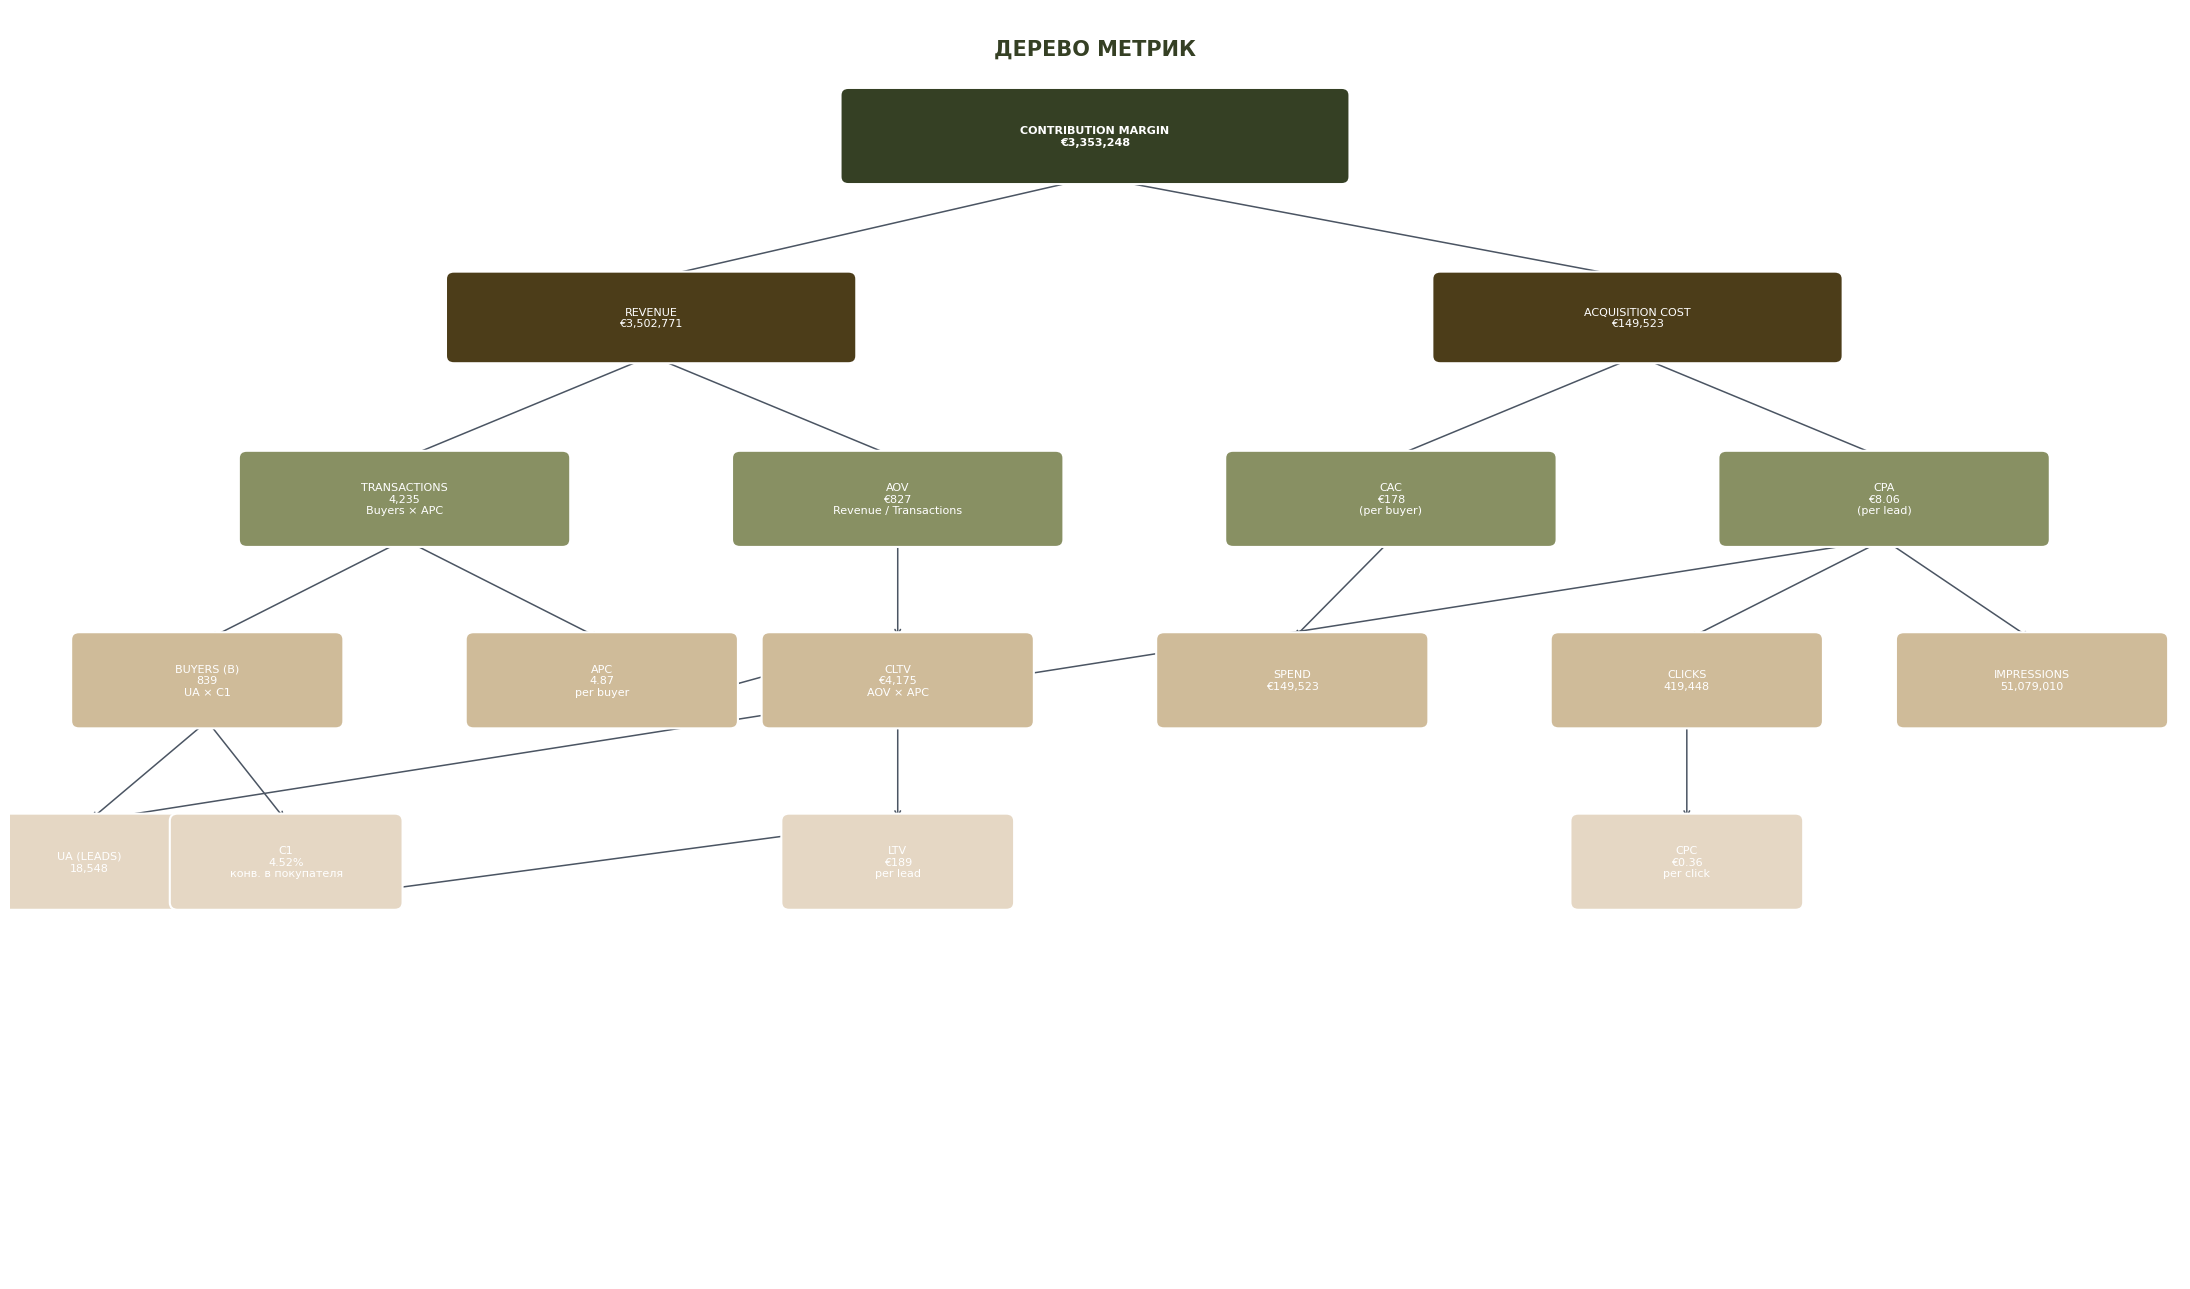

Дерево метрик сохранено: metrics_tree.png


In [95]:
fig, ax = plt.subplots(figsize=(22, 13))
ax.set_xlim(0, 22)
ax.set_ylim(0, 14)
ax.axis("off")

def draw_box(x, y, w, h, text, color, fontsize=8, bold=False):
    ax.add_patch(mpatches.FancyBboxPatch(
        (x - w/2, y - h/2), w, h,
        boxstyle="round,pad=0.08",
        facecolor=color, edgecolor="white", linewidth=1.5, zorder=2
    ))
    ax.text(
        x, y, text,
        ha="center",
        va="center",
        fontsize=fontsize,
        color="white",
        fontweight="bold" if bold else "normal",
        zorder=3
    )

def draw_arrow(p1, p2):
    x1, y1 = nodes[p1][0], nodes[p1][1] - nodes[p1][3]/2
    x2, y2 = nodes[p2][0], nodes[p2][1] + nodes[p2][3]/2
    
    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle="->",
            color="#4B5563",
            lw=1.1
        ),
        zorder=1
    )


APC_val = deals[deals["Is Valid Buyer"]]["Transactions"].mean()
CPC_val = AC / spend["Clicks"].sum()
LTV = CLTV * C1 / 100


# Nodes:
# x, y, width, height, text, color

nodes = {

    "CM": (
        11, 12.6, 5.0, 0.9,
        f"CONTRIBUTION MARGIN\n€{CM:,.0f}",
        "#354024"
    ),

    "REV": (
        6.5, 10.6, 4.0, 0.85,
        f"REVENUE\n€{revenue:,.0f}",
        "#4C3D19"
    ),

    "AC": (
        16.5, 10.6, 4.0, 0.85,
        f"ACQUISITION COST\n€{AC:,.0f}",
        "#4C3D19"
    ),

    "TRX": (
        4, 8.6, 3.2, 0.9,
        f"TRANSACTIONS\n{int(deals['Transactions'].sum()):,}\nBuyers × APC",
        "#889063"
    ),

    "AOV": (
        9, 8.6, 3.2, 0.9,
        f"AOV\n€{AOV:,.0f}\nRevenue / Transactions",
        "#889063"
    ),

    "CAC": (
        14, 8.6, 3.2, 0.9,
        f"CAC\n€{CAC:,.0f}\n(per buyer)",
        "#889063"
    ),

    "CPA": (
        19, 8.6, 3.2, 0.9,
        f"CPA\n€{CPA:.2f}\n(per lead)",
        "#889063"
    ),

    "BUY": (
        2, 6.6, 2.6, 0.9,
        f"BUYERS (B)\n{B:,}\nUA × C1",
        "#CFBB99"
    ),

    "APC": (
        6, 6.6, 2.6, 0.9,
        f"APC\n{APC_val:.2f}\nper buyer",
        "#CFBB99"
    ),

    "CLTV": (
        9, 6.6, 2.6, 0.9,
        f"CLTV\n€{CLTV:,.0f}\nAOV × APC",
        "#CFBB99"
    ),

    "SPEND": (
        13, 6.6, 2.6, 0.9,
        f"SPEND\n€{AC:,.0f}",
        "#CFBB99"
    ),

    "CLICKS": (
        17, 6.6, 2.6, 0.9,
        f"CLICKS\n{int(spend['Clicks'].sum()):,}",
        "#CFBB99"
    ),

    "IMPR": (
        20.5, 6.6, 2.6, 0.9,
        f"IMPRESSIONS\n{int(spend['Impressions'].sum()):,}",
        "#CFBB99"
    ),

    "UA": (
        0.8, 4.6, 2.2, 0.9,
        f"UA (LEADS)\n{UA:,}",
        "#E5D7C4"
    ),

    "C1": (
        2.8, 4.6, 2.2, 0.9,
        f"C1\n{C1:.2f}%\nlead → buyer",
        "#E5D7C4"
    ),

    "LTV": (
        9, 4.6, 2.2, 0.9,
        f"LTV\n€{LTV:,.0f}\nper lead",
        "#E5D7C4"
    ),

    "CPC": (
        17, 4.6, 2.2, 0.9,
        f"CPC\n€{CPC_val:.2f}\nper click",
        "#E5D7C4"
    ),
}


for key, (x, y, w, h, text, color) in nodes.items():
    draw_box(
        x, y, w, h,
        text,
        color,
        fontsize=8,
        bold=(key == "CM")
    )


edges = [
    ("CM", "REV"),
    ("CM", "AC"),

    ("REV", "TRX"),
    ("REV", "AOV"),

    ("AC", "CAC"),
    ("AC", "CPA"),

    ("TRX", "BUY"),
    ("TRX", "APC"),

    ("AOV", "CLTV"),
    ("APC", "CLTV"),

    ("CAC", "SPEND"),
    ("CPA", "CLICKS"),
    ("CPA", "IMPR"),
    ("CPA", "UA"),

    ("BUY", "UA"),
    ("BUY", "C1"),

    ("CLTV", "LTV"),
    ("C1", "LTV"),

    ("CLICKS", "CPC"),
]


for parent, child in edges:
    draw_arrow(parent, child)


ax.text(
    11,
    13.5,
    "METRIC TREE",
    ha="center",
    fontsize=15,
    fontweight="bold",
    color="#354024"
)

plt.tight_layout()

plt.savefig(
    "../data/clean/metrics_tree.png",
    dpi=150,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Metric tree saved: metrics_tree.png")

# SLA-Bins

In [87]:
sla_bins = [0, 5, 15, 60, 120, 300, 600, 900, 1200, 1440, float("inf")]
sla_labels = [
    "< 5 min",
    "5-15 min",
    "15-60 min",
    "1-2 h",
    "2-5 h",
    "5-10 h",
    "10-15 h",
    "15-20 h",
    "20-24 h",
    ">= 24 h"
]

deals_sla = deals[deals["SLA Minutes"].notna()].copy()

deals_sla["SLA Bucket"] = pd.cut(
    deals_sla["SLA Minutes"],
    bins=sla_bins,
    labels=sla_labels
)

# Update the main dataset as well
deals["SLA Bucket"] = pd.cut(
    deals["SLA Minutes"],
    bins=sla_bins,
    labels=sla_labels
)

# Detailed bucket analysis
sla_analysis = (
    deals_sla
    .groupby("SLA Bucket", observed=True)
    .agg(
        total_leads=      ("Id",            "count"),
        true_buyers=      ("Is Valid Buyer","sum"),
        avg_revenue=      ("Revenue",       "mean"),
        total_revenue=    ("Revenue",       "sum"),
        avg_sla_minutes=  ("SLA Minutes",   "mean"),
    )
    .reset_index()
)

# Conversion rate from the TOTAL number of leads (UA = 18,548)
# This shows the contribution of each SLA bucket to the overall C1
sla_analysis["c1_contribution"] = (
    sla_analysis["true_buyers"] / UA * 100
).round(4)

# Conversion rate within the bucket (share of buyers among leads in this bucket)
sla_analysis["c1_within_bucket"] = (
    sla_analysis["true_buyers"] / sla_analysis["total_leads"] * 100
).round(2)

print("SLA analysis by detailed buckets:")
print(sla_analysis[[
    "SLA Bucket", "total_leads", "true_buyers",
    "c1_contribution", "c1_within_bucket", "avg_revenue"
]].to_string(index=False))

# Groups for A/B test
# Group A (control): SLA > 30 min
# Group B (test): SLA <= 30 min (< 5 min + 5-15 min + 15-60 min)
fast_buckets = ["< 5 min", "5-15 min", "15-60 min"]
slow_buckets = ["1-2 h", "2-5 h", "5-10 h",
                "10-15 h", "15-20 h", "20-24 h", ">= 24 h"]

group_fast = deals_sla[deals_sla["SLA Bucket"].isin(fast_buckets)]
group_slow = deals_sla[deals_sla["SLA Bucket"].isin(slow_buckets)]

c1_fast = group_fast["Is Valid Buyer"].sum() / UA * 100
c1_slow = group_slow["Is Valid Buyer"].sum() / UA * 100

print(f"\nFAST GROUP (SLA ≤ 60 min):")
print(f"  Leads    : {len(group_fast):,}")
print(f"  Buyers   : {group_fast['Is Valid Buyer'].sum():,}")
print(f"  C1 contribution : {c1_fast:.2f}% of all UA")

print(f"\nSLOW GROUP (SLA > 60 min):")
print(f"  Leads    : {len(group_slow):,}")
print(f"  Buyers   : {group_slow['Is Valid Buyer'].sum():,}")
print(f"  C1 contribution : {c1_slow:.2f}% of all UA")

SLA-анализ по детальным корзинам:
SLA Bucket  total_leads  true_buyers  c1_contribution  c1_within_bucket  avg_revenue
   < 5 min          239           12           0.0647              5.02   301.673640
  5-15 min          749           51           0.2750              6.81   308.644860
 15-60 min         2484          145           0.7818              5.84   257.912641
     1-2 h         1581           93           0.5014              5.88   257.685009
     2-5 h         2418          122           0.6578              5.05   222.557899
    5-10 h         1598           80           0.4313              5.01   175.381727
   10-15 h         2252          127           0.6847              5.64   219.147425
   15-20 h         1757           83           0.4475              4.72   211.018782
   20-24 h          594           22           0.1186              3.70   153.804714
   >= 24 h         1861           81           0.4367              4.35   241.759807

Группа БЫСТРЫХ (SLA ≤ 60 мин):

# BLOCK 4: HYPOTHESES AND HADI CYCLES

# 9. HYPOTHESES: SLA -> C1

In [89]:
# H: If the first response time is reduced to 30 minutes,
# conversion C1 will increase by at least 1%.

# Why exactly 30 min, not 5:
# The graph shows that the "15-60 min" bucket generates
# the highest number of buyers (143). This means
# the school has the capacity to respond within this window.
# The test goal is to move leads from 1-2h, 2-5h and later
# into the ≤ 60 min bucket through automation.

print("═" * 70)
print("  HADI CYCLE — HYPOTHESIS 1")
print("  SLA ≤ 30 min -> C1 growth")
print("═" * 70)

# ── H: Formulation ──────────────────────────────────────────
no_response     = deals["SLA Minutes"].isna().sum()
no_response_pct = no_response / len(deals) * 100

print(f"\n  H (HYPOTHESIS):")
print(f"  ───────────────────────────────────────────────────")
print(f"  H0: Ensuring SLA ≤ 30 min does not affect C1")
print(f"  H1: Ensuring SLA ≤ 30 min increases C1")
print(f"      by ≥ 1% (absolute change)")
print()
print(f"  Current problem from data:")
print(f"  • {no_response:,} leads ({no_response_pct:.1f}%) did not")
print(f"    receive any response (SLA = NaN)")
print(f"  • Most buyers are concentrated in")
print(f"    15-60 min and 2-5 h buckets, meaning")
print(f"    managers respond inconsistently")
print(f"  • Buyers in < 5 min = only 11, the potential")
print(f"    of this bucket is significantly underused")

# ── A: Action ──────────────────────────────────────────────
print(f"\n  A (ACTION):")
print(f"  ───────────────────────────────────────────────────")
print(f"  Group A (control, 50% of leads):")
print(f"    Current process without changes")
print()
print(f"  Group B (test, 50% of leads):")
print(f"    • Automatic SMS/WhatsApp to lead after 2 minutes")
print(f"      (while manager prepares for the call)")
print(f"    • Push notification to manager: call ≤ 30 min")
print(f"    • If there is no call within 30 min ->")
print(f"      escalation to the next available manager")
print(f"  Split: random by Contact Id parity")

# ── D: Data ────────────────────────────────────────────────
print(f"\n  D (DATA — collect for 14 days):")
print(f"  ───────────────────────────────────────────────────")
print(f"  Main metric       : C1 = True Buyers / UA")
print(f"  Secondary metrics : Deal Duration Days,")
print(f"                      Revenue per lead")
print(f"  Guardrail metrics : Lost 'No Answer' does not grow,")
print(f"                      manager NPS does not decrease")

# ── I: Sample size calculation ────────────────────────────────
ALPHA  = 0.05
POWER  = 0.80
UA     = 18548
z_a    = norm.ppf(1 - ALPHA)          # one-sided
z_b    = norm.ppf(POWER)

p1     = C1 / 100                     # current C1
p2     = p1 + 0.01                    # target +1%
p_avg  = (p1 + p2) / 2

n_per_group = int(np.ceil(
    (z_a * np.sqrt(2 * p_avg * (1 - p_avg))
     + z_b * np.sqrt(p1*(1-p1) + p2*(1-p2))) ** 2
    / (p2 - p1) ** 2
))

daily_leads  = UA / 365
days_needed  = (n_per_group * 2) / daily_leads
revenue_uplt = (p2 - p1) * UA * AOV

print(f"\n  I (INSIGHTS — test statistics):")
print(f"  ───────────────────────────────────────────────────")
print(f"  Test type              : z-test for proportions")
print(f"                           one-sided")
print(f"  α (significance level) : {ALPHA}")
print(f"  1-β (test power)       : {POWER}")
print(f"  p1 (current C1)        : {p1:.4f}  ({C1:.2f}%)")
print(f"  p2 (target C1)         : {p2:.4f}  ({p2*100:.2f}%)")
print(f"  MDE                    : +1.00% absolute")
print(f"  Required per group     : {n_per_group:,} leads")
print(f"  Leads per day          : {daily_leads:.0f}")
print(f"  Duration               : {days_needed:.0f} days")
print()
if days_needed <= 14:
    print(f" Test fits into 14 days")
else:
    # Calculate MDE for a 14-day test
    n_14 = int(daily_leads * 14 / 2)
    # Find MDE by iteration
    for mde_try in [0.005, 0.003, 0.002, 0.001]:
        p2_try  = p1 + mde_try
        p_a_try = (p1 + p2_try) / 2
        n_try   = int(np.ceil(
            (z_a * np.sqrt(2 * p_a_try*(1-p_a_try))
             + z_b * np.sqrt(p1*(1-p1) + p2_try*(1-p2_try)))**2
            / mde_try**2
        ))
        days_try = (n_try * 2) / daily_leads
        if days_try <= 14:
            print(f"  At MDE +1% test takes {days_needed:.0f} days")
            print(f"  Solution: reduce MDE to +{mde_try*100:.1f}%")
            print(f"  -> Then required {n_try:,}/group")
            print(f"  -> Test duration {days_try:.0f} days")
            revenue_uplt_adj = mde_try * UA * AOV
            print(f"  Potential (adj): {revenue_uplt_adj:,.0f}€")
            break

print(f"\n  Financial impact:")
print(f"  Potential (+1% C1) : €{revenue_uplt:,.0f}")
print(f"  Current revenue    : €{revenue:,.0f}")
print(f"  Growth             : +{revenue_uplt/revenue*100:.1f}%")
print("═" * 70)

# ── A/B RESULT SIMULATION (based on historical data) ────────
print(f"\n  SIMULATION: result if the test had already been completed")
print(f"  (based on historical SLA data)")
print(f"  ───────────────────────────────────────────────────")

# Control group: leads with SLA > 30 min
ctrl = deals_sla[
    deals_sla["SLA Minutes"] > 30
]["Is Valid Buyer"].values

# Test group: leads with SLA ≤ 30 min
test = deals_sla[
    deals_sla["SLA Minutes"] <= 30
]["Is Valid Buyer"].values

if len(ctrl) > 0 and len(test) > 0:
    # Chi-square test for proportions
    from scipy.stats import chi2_contingency

    ctrl_paid = ctrl.sum()
    ctrl_not  = len(ctrl) - ctrl_paid
    test_paid = test.sum()
    test_not  = len(test) - test_paid

    contingency = np.array([
        [test_paid, test_not],
        [ctrl_paid, ctrl_not]
    ])

    chi2, p_value, dof, expected = chi2_contingency(
        contingency, correction=False
    )

    c1_ctrl = ctrl_paid / len(ctrl) * 100
    c1_test = test_paid / len(test) * 100

    print(f"  Control group (SLA > 30 min):")
    print(f"    Leads     : {len(ctrl):,}")
    print(f"    Buyers    : {ctrl_paid:,}")
    print(f"    C1 within : {c1_ctrl:.2f}%")
    print()
    print(f"  Test group (SLA ≤ 30 min):")
    print(f"    Leads     : {len(test):,}")
    print(f"    Buyers    : {test_paid:,}")
    print(f"    C1 within : {c1_test:.2f}%")
    print()
    print(f"  Chi-square statistic : {chi2:.4f}")
    print(f"  p-value              : {p_value:.6f}")
    print()
    if p_value < ALPHA:
        print(f"  ✅ p-value < {ALPHA} — difference is statistically")
        print(f"     significant. H1 hypothesis is confirmed")
        print(f"     on historical data.")
    else:
        print(f"  ⚠️  p-value = {p_value:.4f} > {ALPHA}")
        print(f"     No statistically significant difference")
        print(f"     on historical data.")
        print(f"     A test on new data is still required —")
        print(f"     historical data is biased (survivorship).")

══════════════════════════════════════════════════════════════════════
  HADI-ЦИКЛ — ГИПОТЕЗА 1
  SLA ≤ 30 мин -> C1 рост
══════════════════════════════════════════════════════════════════════

  H (HYPOTHESIS):
  ───────────────────────────────────────────────────
  H0: Обеспечение SLA ≤ 30 мин не влияет на C1
  H1: Обеспечение SLA ≤ 30 мин увеличивает C1
      на ≥ 1% (абсолютное изменение)

  Текущая проблема из данных:
  • 6,060 лидов (28.1%) вообще
    не получили ответа (SLA = NaN)
  • Большинство buyers сконцентрированы в
    корзинах 15-60 мин и 2-5 ч, это значит
    менеджеры отвечают неравномерно
  • Buyers в < 5 мин = всего 11, потенциал
    этой корзины сильно недоиспользован

  A (ACTION):
  ───────────────────────────────────────────────────
  Группа A (контроль, 50% лидов):
    Текущий процесс без изменений

  Группа B (тест, 50% лидов):
    • Авто-SMS/WhatsApp лиду через 2 минуты
      (пока менеджер готовится к звонку)
    • Push-уведомление менеджеру: звонок ≤ 30 мин


### Conclusion on hypothesis H1

I wanted to test whether responding to customers **within 30 minutes** would help increase the conversion rate to purchase (C1).

The analysis showed that **28.1% of leads (6,060 people) did not receive any response at all**. This indicates a significant opportunity to improve the lead processing process.

According to historical data, leads who received a response **within 30 minutes** converted to buyers more often:

* **SLA ≤ 30 minutes — C1 = 6.09%**
* **SLA > 30 minutes — C1 = 5.12%**

The difference is 0.97%, which is very close to the target improvement of +1%.

This means that faster response time is associated with a higher conversion rate.

However, the statistical test showed **p-value = 0.0608**, which is slightly above the significance threshold of **0.05**. Therefore, the observed difference is **not yet statistically significant**, and we cannot confidently conclude that faster response time itself caused the increase in conversion. Other factors may have influenced the result.

Nevertheless, the results are promising. If the company manages to reduce response time to within 30 minutes for all leads, this could increase conversion and generate approximately **€153K in additional revenue**.

Therefore, the next recommended step is to run an **A/B test** to accurately verify whether faster response times truly increase the number of buyers.



# VISUALIZATIONS FOR HYPOTHESIS 1

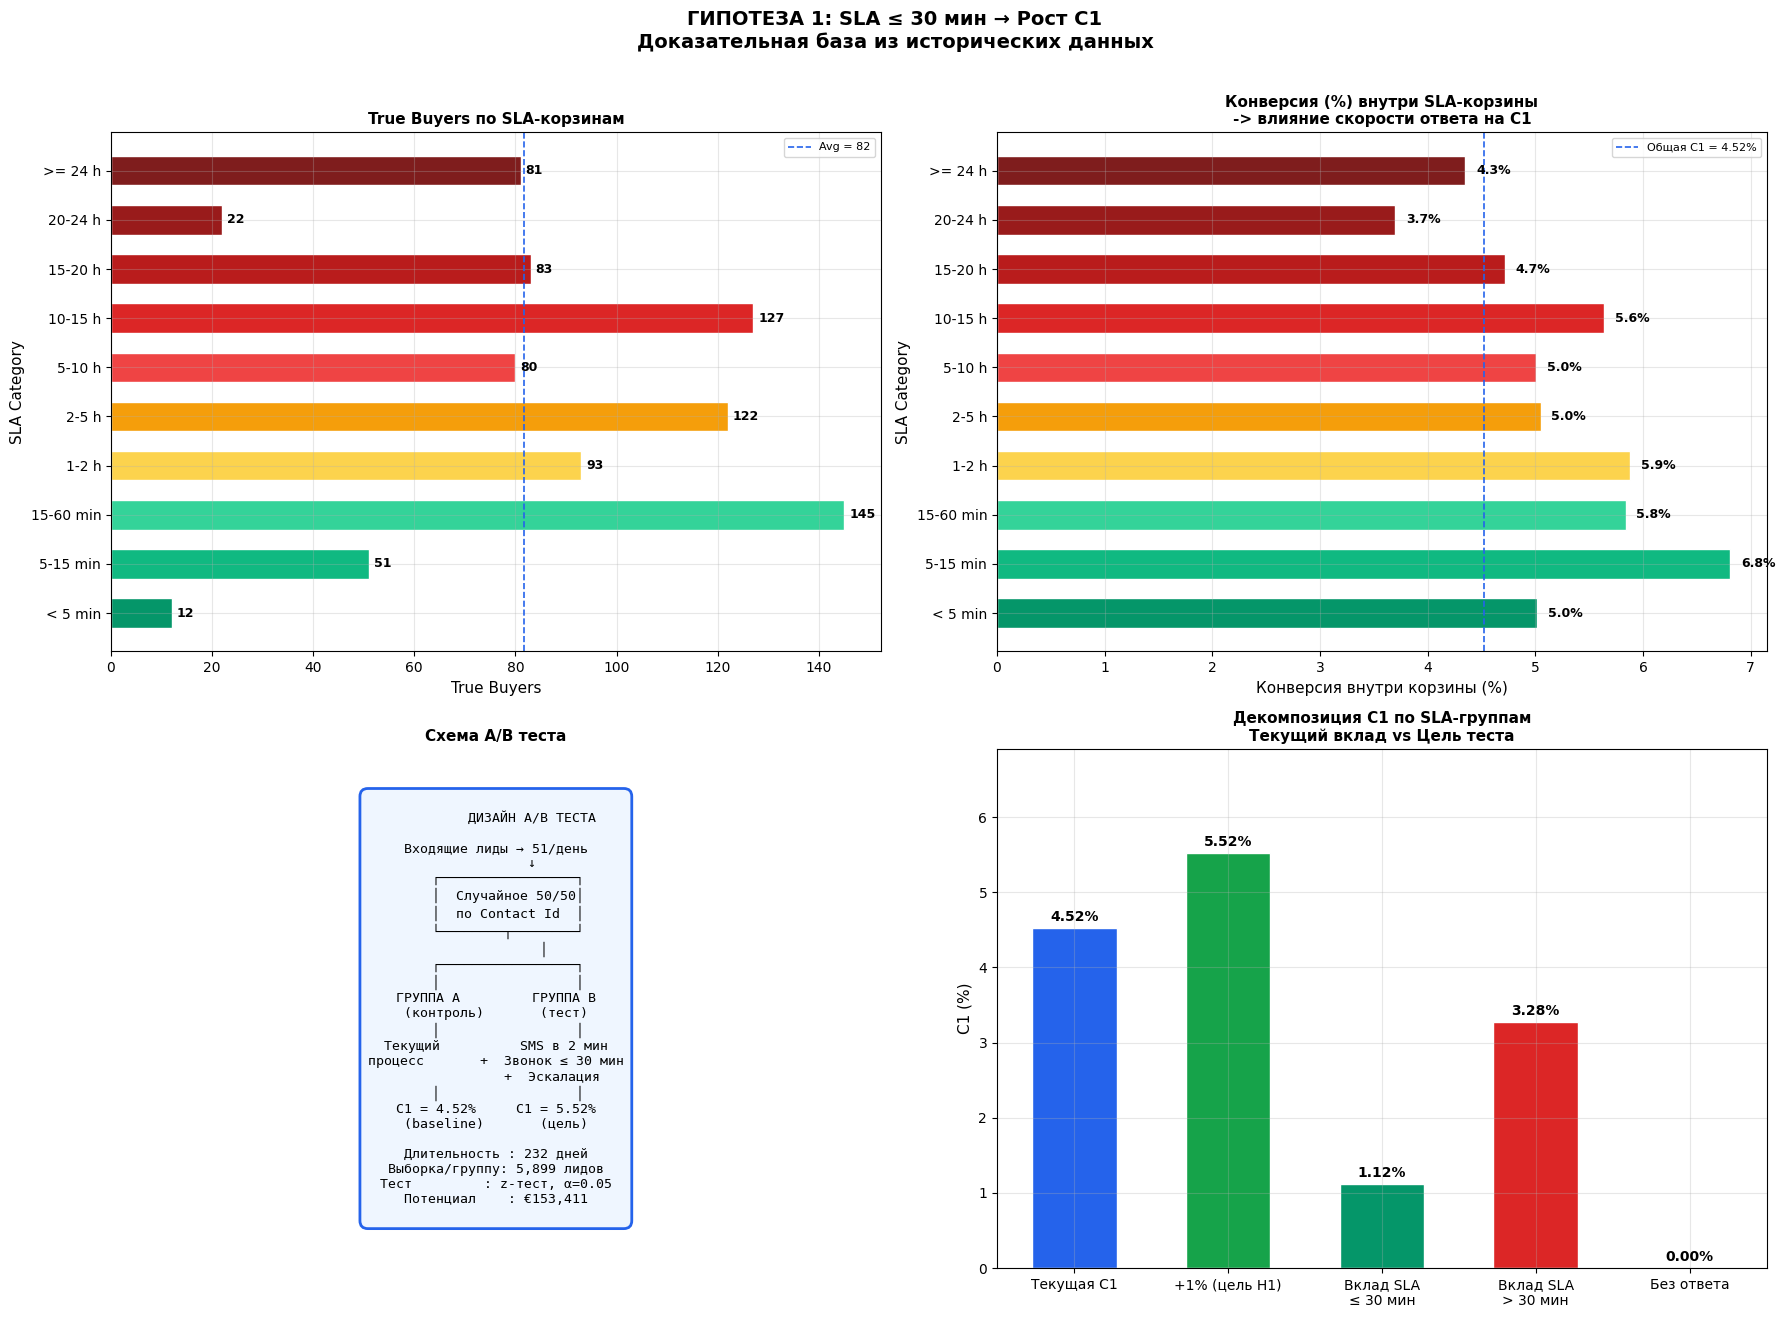

Сохранено: hypothesis1_full.png


In [92]:
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle(
    "HYPOTHESIS 1: SLA ≤ 30 min → C1 Growth\n"
    "Evidence Base from Historical Data",
    fontsize=14, fontweight="bold", y=1.01
)

# Colors by SLA bucket (from green to red)
bucket_colors = {
    "< 5 min"  : "#059669",
    "5-15 min" : "#10B981",
    "15-60 min": "#34D399",
    "1-2 h"    : "#FCD34D",
    "2-5 h"    : "#F59E0B",
    "5-10 h"   : "#EF4444",
    "10-15 h"  : "#DC2626",
    "15-20 h"  : "#B91C1C",
    "20-24 h"  : "#991B1B",
    ">= 24 h"  : "#7F1D1D",
}

# ── GRAPH 1: True Buyers by SLA ─────────────────────────────
ax1 = axes[0, 0]

plot_data = sla_analysis.copy()
plot_colors = [
    bucket_colors.get(str(b), "#6B7280")
    for b in plot_data["SLA Bucket"]
]

bars = ax1.barh(
    plot_data["SLA Bucket"].astype(str),
    plot_data["true_buyers"],
    color=plot_colors,
    edgecolor="white", height=0.6
)

for bar, val in zip(bars, plot_data["true_buyers"]):
    if val > 0:
        ax1.text(
            bar.get_width() + 1,
            bar.get_y() + bar.get_height() / 2,
            str(int(val)),
            va="center", fontsize=9, fontweight="bold"
        )

# Reference line — average
avg_buyers = plot_data["true_buyers"].mean()
ax1.axvline(
    avg_buyers, color="#2563EB",
    linestyle="--", linewidth=1.2,
    label=f"Avg = {avg_buyers:.0f}"
)
ax1.legend(fontsize=8)
ax1.set_title("True Buyers by SLA Bucket",
              fontsize=11, fontweight="bold")
ax1.set_xlabel("True Buyers")
ax1.set_ylabel("SLA Category")

# ── GRAPH 2: C1 within bucket ────────────────────────────────
ax2 = axes[0, 1]

bars2 = ax2.barh(
    plot_data["SLA Bucket"].astype(str),
    plot_data["c1_within_bucket"],
    color=plot_colors,
    edgecolor="white", height=0.6
)

for bar, val in zip(bars2, plot_data["c1_within_bucket"]):
    if val > 0:
        ax2.text(
            bar.get_width() + 0.1,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%",
            va="center", fontsize=9, fontweight="bold"
        )

ax2.axvline(
    C1, color="#2563EB", linestyle="--", linewidth=1.2,
    label=f"Overall C1 = {C1:.2f}%"
)
ax2.legend(fontsize=8)
ax2.set_title("Conversion (%) within SLA Bucket\n"
              "→ Impact of Response Speed on C1",
              fontsize=11, fontweight="bold")
ax2.set_xlabel("Conversion within bucket (%)")
ax2.set_ylabel("SLA Category")

# ── GRAPH 3: A/B Test Design ─────────────────────────────────
ax3 = axes[1, 0]
ax3.axis("off")

ab_text = f"""
         A/B TEST DESIGN
         
Incoming leads → {daily_leads:.0f}/day
         ↓
   ┌─────────────────┐
   │  Random 50/50   │
   │  by Contact Id  │
   └────────┬────────┘
            │
   ┌─────────────────┐
   │                 │
GROUP A          GROUP B
(Control)        (Test)
   │                 │
Current         SMS after 2 min
process      +  Call ≤ 30 min
             +  Escalation
   │                 │
C1 = {C1:.2f}%     C1 = {(C1+1):.2f}%
(baseline)       (target)

Duration     : {days_needed:.0f} days
Sample/group : {n_per_group:,} leads
Test         : z-test, α=0.05
Potential    : €{revenue_uplt:,.0f}
"""

ax3.text(
    0.5, 0.5, ab_text,
    transform=ax3.transAxes,
    fontsize=9.5, va="center", ha="center",
    fontfamily="monospace",
    bbox=dict(
        boxstyle="round,pad=0.6",
        facecolor="#EFF6FF",
        edgecolor="#2563EB", linewidth=2
    )
)
ax3.set_title("A/B Test Structure",
              fontsize=11, fontweight="bold")

# ── GRAPH 4: Waterfall — Current vs Potential C1 ─────────────
ax4 = axes[1, 1]

categories_wf = [
    "Current C1",
    "+1% (H1 target)",
    "Contribution SLA\n≤ 30 min",
    "Contribution SLA\n> 30 min",
    "No response"
]

# Calculate contributions
contrib_fast = (
    group_fast["Is Valid Buyer"].sum() / UA * 100
)
contrib_slow = (
    group_slow["Is Valid Buyer"].sum() / UA * 100
)
contrib_nan = 0  # leads without response do not convert

values_wf = [
    C1,
    C1 + 1.0,
    contrib_fast,
    contrib_slow,
    contrib_nan
]

colors_wf = [
    "#2563EB",
    "#16A34A",
    "#059669",
    "#DC2626",
    "#9CA3AF"
]

bars4 = ax4.bar(
    categories_wf,
    values_wf,
    color=colors_wf,
    edgecolor="white",
    width=0.55
)

for bar, val in zip(bars4, values_wf):
    ax4.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"{val:.2f}%",
        ha="center", va="bottom",
        fontsize=10, fontweight="bold"
    )

ax4.set_title("C1 Decomposition by SLA Groups\n"
              "Current Contribution vs Test Target",
              fontsize=11, fontweight="bold")
ax4.set_ylabel("C1 (%)")
ax4.set_ylim(0, max(values_wf) * 1.25)

plt.tight_layout()
plt.savefig(
    "../data/clean/hypothesis1_full.png",
    dpi=150, bbox_inches="tight", facecolor="white"
)
plt.show()
print("Saved: hypothesis1_full.png")

# 10. Final growth opportunities table

Task was destroyed but it is pending!
task: <Task pending name='Task-717' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-718' coro=<Kernel.shell_main() running at /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-718' coro=<Kernel.shell_main() running at /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>



══════════════════════════════════════════════════════════════════════
  ИТОГОВАЯ ТАБЛИЦА ТОЧЕК РОСТА БИЗНЕСА
══════════════════════════════════════════════════════════════════════

┌─────────────────────────────────────────────────────────────┐
│  ГИПОТЕЗА 1: SLA ≤ 30 мин → C1 +1%                        │
│  Тип: A/B тест для пропорций                                │
├─────────────────────────────────────────────────────────────┤
│                                                             │
│  ПРОБЛЕМА (из данных):                                      │
│  • 6,060 лидов (28.1%) без ответа вообще          │
│  • Медианное SLA = 332 мин — большинство       │
│    лидов ждут ответа часами                                 │
│  • Корзина < 5 мин = только 11 buyers из 839                │
│    (потенциал крайне недоиспользован)                       │
│                                                             │
│  МЕТРИКА        : C1 (True Buyers / UA)                     │
│  ТЕКУЩЕЕ

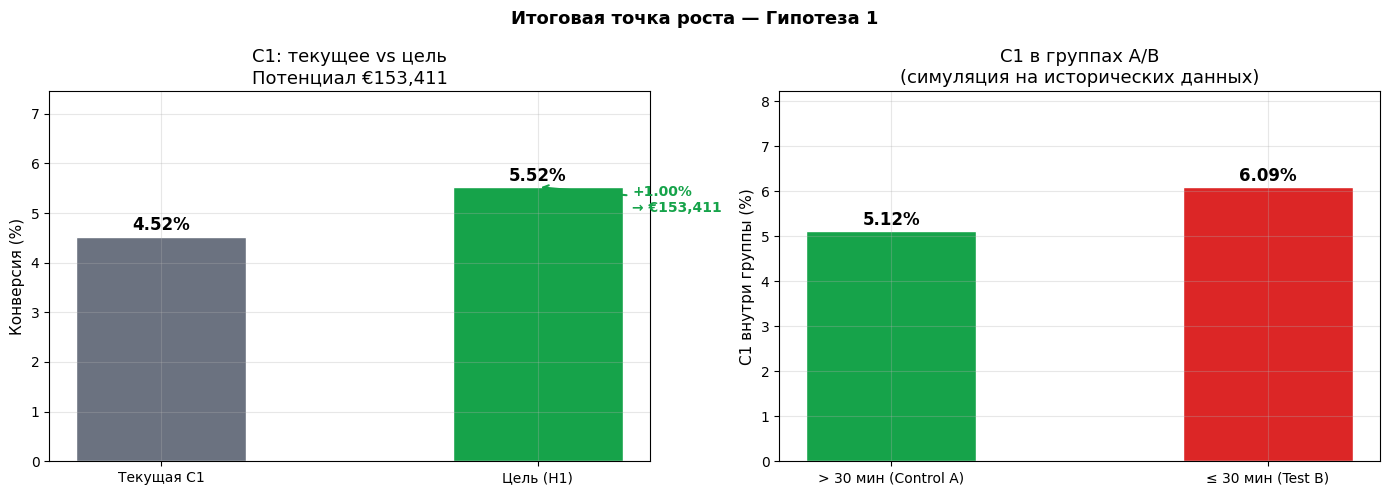

Сохранено: growth_point_h1.png
══════════════════════════════════════════════════════════════════════


In [94]:
print()
print("═" * 70)
print("  FINAL BUSINESS GROWTH OPPORTUNITIES TABLE")
print("═" * 70)

print(f"""
┌─────────────────────────────────────────────────────────────┐
│  HYPOTHESIS 1: SLA ≤ 30 min → C1 +1%                       │
│  Type: A/B test for proportions                             │
├─────────────────────────────────────────────────────────────┤
│                                                             │
│  PROBLEM (from data):                                      │
│  • {no_response:,} leads ({no_response_pct:.1f}%) received no response at all │
│  • Median SLA = {deals_sla["SLA Minutes"].median():.0f} min — most leads      │
│    wait for hours for a response                           │
│  • < 5 min bucket = only 11 buyers out of 839               │
│    (extremely underutilized potential)                     │
│                                                             │
│  METRIC         : C1 (True Buyers / UA)                     │
│  CURRENT        : {C1:.2f}%                                 │
│  TARGET         : {(C1+1):.2f}% (+1.00% absolute)            │
│                                                             │
│  ACTION:                                                    │
│  Automated SMS to lead within 2 min + manager call ≤ 30 min │
│  + escalation if there is no response                      │
│                                                             │
│  TEST:                                                      │
│  One-sided z-test for proportions                           │
│  α = 0.05, power = 0.80                                    │
│  Sample size: {n_per_group:,} leads/group                  │
│  Duration: {days_needed:.0f} days                           │
│                                                             │
│  GUARDRAIL METRICS:                                        │
│  • Lost 'No Answer' does not increase in group B            │
│  • Manager NPS does not decrease                           │
│                                                             │
│  FINANCIAL IMPACT:                                         │
│  Potential    : €{revenue_uplt:,.0f}                        │
│  Revenue growth: +{revenue_uplt/revenue*100:.1f}% vs current │
│  Costs        : ~€0 (only CRM setup)                       │
│  Priority     : FIRST PRIORITY                             │
│                                                             │
└─────────────────────────────────────────────────────────────┘
""")

# Final growth opportunity chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Final Growth Opportunity — Hypothesis 1",
             fontsize=13, fontweight="bold")

# Chart 1: current vs target
axes[0].bar(
    ["Current C1", "Target (H1)"],
    [C1, C1 + 1.0],
    color=["#6B7280", "#16A34A"],
    edgecolor="white", width=0.45
)
for rect in axes[0].patches:
    h = rect.get_height()
    axes[0].text(
        rect.get_x() + rect.get_width()/2,
        h + 0.05, f"{h:.2f}%",
        ha="center", va="bottom",
        fontsize=12, fontweight="bold"
    )
axes[0].set_ylabel("Conversion (%)")
axes[0].set_ylim(0, (C1 + 1.0) * 1.35)
axes[0].set_title(f"C1: current vs target\n"
                  f"Potential €{revenue_uplt:,.0f}")
axes[0].annotate(
    f"+1.00%\n→ €{revenue_uplt:,.0f}",
    xy=(1, C1 + 1.0),
    xytext=(1.25, C1 + 0.5),
    fontsize=10, color="#16A34A", fontweight="bold",
    arrowprops=dict(arrowstyle="->",
                    color="#16A34A", lw=1.5)
)

# Chart 2: SLA group contribution to C1
sla_ab_groups = deals_sla.copy()
sla_ab_groups["AB Group"] = np.where(
    sla_ab_groups["SLA Minutes"] <= 30,
    "≤ 30 min (Test B)",
    "> 30 min (Control A)"
)
ab_summary = (
    sla_ab_groups
    .groupby("AB Group")
    .agg(
        leads=  ("Id",             "count"),
        buyers= ("Is Valid Buyer", "sum"),
    )
    .reset_index()
)
ab_summary["c1_within"] = (
    ab_summary["buyers"] / ab_summary["leads"] * 100
)

axes[1].bar(
    ab_summary["AB Group"],
    ab_summary["c1_within"],
    color=["#16A34A", "#DC2626"],
    edgecolor="white", width=0.45
)
for rect in axes[1].patches:
    h = rect.get_height()
    axes[1].text(
        rect.get_x() + rect.get_width()/2,
        h + 0.05, f"{h:.2f}%",
        ha="center", va="bottom",
        fontsize=12, fontweight="bold"
    )
axes[1].set_ylabel("C1 within group (%)")
axes[1].set_ylim(0, ab_summary["c1_within"].max() * 1.35)
axes[1].set_title("C1 in A/B groups\n(simulation based on historical data)")

plt.tight_layout()
plt.savefig(
    "../data/clean/growth_point_h1.png",
    dpi=150, bbox_inches="tight", facecolor="white"
)
plt.show()
print("Saved: growth_point_h1.png")
print("═" * 70)